# 02: Qiskit の基本操作

Qiskit で量子回路を作り、状態を確認するまでの最小限の流れを学ぶ。

**内容:**
1. 1量子ビットの回路：$X$ ゲートでビットを反転する
2. 重ね合わせ：$H$ ゲートで $\vert+\rangle$ を作る
3. 2量子ビットのもつれ：ベル状態を作る

In [10]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np

## 1. ビット反転：$X$ ゲート

$\vert 0\rangle$ を $\vert 1\rangle$ にひっくり返す、最も単純な回路。

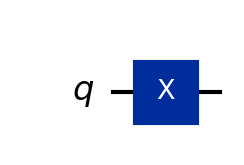

In [11]:
# 1量子ビットの回路を作る
qc = QuantumCircuit(1)

# X ゲート（ビット反転）を掛ける
qc.x(0)

# 状態ベクトルを確認する
sv = Statevector.from_instruction(qc)

print("状態ベクトル:", np.array(sv).round(4))
print()
for i, amp in enumerate(sv):
    print(f"  |{i}⟩ の振幅: {amp:.4f}  確率: {abs(amp)**2:.4f}")

状態ベクトル: [0.+0.j 1.+0.j]

  |0⟩ の振幅: 0.0000+0.0000j  確率: 0.0000
  |1⟩ の振幅: 1.0000+0.0000j  確率: 1.0000


**コードの解説:**

- `QuantumCircuit(1)`: 1量子ビットの空の回路を作る。引数の数字が量子ビット数。初期状態は $\vert 0\rangle$。
- `qc.x(0)`: $q_0$ に $X$ ゲートを適用する。$X\vert 0\rangle = \vert 1\rangle$、$X\vert 1\rangle = \vert 0\rangle$。

**コードの解説:**

- `Statevector.from_instruction(qc)`: 回路を $\vert 0\rangle$ から実行したときの最終状態ベクトルを計算する。実機を使わずシミュレーションで直接求める方法。
- `np.array(sv)`: 状態ベクトルを配列として取得する。1量子ビットなら要素は2つ（$\vert 0\rangle$ と $\vert 1\rangle$ の振幅）。
- `abs(amp)**2`: 振幅の絶対値の2乗が測定確率になる（ボルンの規則）。
- 出力中の `j` は虚数単位（数学の $i$）。Python では電気工学の慣習に従い `j` を使う。

$\vert 0\rangle$ の振幅が 0、$\vert 1\rangle$ の振幅が 1 なので、測定すれば 100% の確率で 1 が出る。

## 2. 重ね合わせ：$H$ ゲート

$\vert 0\rangle$ にアダマールゲートを掛けて、$\vert 0\rangle$ と $\vert 1\rangle$ の重ね合わせ $\vert+\rangle = \frac{\vert 0\rangle + \vert 1\rangle}{\sqrt{2}}$ を作る。

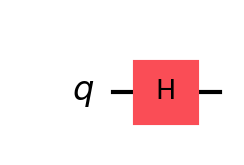

In [12]:
qc2 = QuantumCircuit(1)
qc2.h(0)  # アダマールゲート

# 状態ベクトルを確認
sv2 = Statevector.from_instruction(qc2)

print("状態ベクトル:", np.array(sv2).round(4))
print()
for i, amp in enumerate(sv2):
    print(f"  |{i}⟩ の振幅: {amp:.4f}  確率: {abs(amp)**2:.4f}")

print()
print("→ |0⟩ と |1⟩ の振幅がどちらも 1/√2 ≈ 0.7071。")
print("  測定すると 0 か 1 がそれぞれ 50% の確率で出る。")

状態ベクトル: [0.7071+0.j 0.7071+0.j]

  |0⟩ の振幅: 0.7071+0.0000j  確率: 0.5000
  |1⟩ の振幅: 0.7071+0.0000j  確率: 0.5000

→ |0⟩ と |1⟩ の振幅がどちらも 1/√2 ≈ 0.7071。
  測定すると 0 か 1 がそれぞれ 50% の確率で出る。


**コードの解説:**

- `qc2.h(0)`: $q_0$ にアダマールゲート $H$ を適用する。$H\vert 0\rangle = \frac{\vert 0\rangle + \vert 1\rangle}{\sqrt{2}}$。

## 3. もつれ：ベル状態

2量子ビットで $H$ + CNOT を掛けて、ベル状態 $\frac{\vert 00\rangle + \vert 11\rangle}{\sqrt{2}}$ を作る。

2つのビットが「もつれた」状態になり、一方を測定すると他方の結果も確定する。

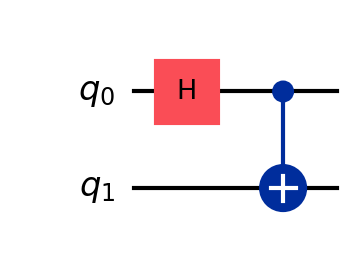

In [13]:
qc3 = QuantumCircuit(2)
qc3.h(0)       # 上のワイヤーに H
qc3.cx(0, 1)   # CNOT: q_0(制御) → q_1(標的)

# 状態ベクトルを確認
sv3 = Statevector.from_instruction(qc3)

print("状態ベクトル:", np.array(sv3).round(4))
print()
for i, amp in enumerate(sv3):
    if abs(amp) > 1e-10:
        q0 = i & 1
        q1 = (i >> 1) & 1
        print(f"  |{i:02b}⟩ の振幅: {amp:.4f}  → q_0={q0}, q_1={q1}")

print()
print("→ |00⟩ と |11⟩ だけが現れる。")
print("  q_0 を測って 0 なら q_1 も必ず 0。")
print("  q_0 を測って 1 なら q_1 も必ず 1。")
print("  これが量子もつれ（エンタングルメント）である。")

状態ベクトル: [0.7071+0.j 0.    +0.j 0.    +0.j 0.7071+0.j]

  |00⟩ の振幅: 0.7071+0.0000j  → q_0=0, q_1=0
  |11⟩ の振幅: 0.7071+0.0000j  → q_0=1, q_1=1

→ |00⟩ と |11⟩ だけが現れる。
  q_0 を測って 0 なら q_1 も必ず 0。
  q_0 を測って 1 なら q_1 も必ず 1。
  これが量子もつれ（エンタングルメント）である。


**コードの解説:**

- `QuantumCircuit(2)`: 2量子ビットの回路。初期状態は $\vert 00\rangle$。
- `qc3.cx(0, 1)`: CNOT ゲート。第1引数が制御ビット、第2引数が標的ビット。制御ビットが $\vert 1\rangle$ のとき標的ビットを反転する。